In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [17]:
PROJECT_ROOT = Path("..")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

features = pd.read_parquet(DATA_PROCESSED / "features.parquet")

features.shape

(2396, 180)

In [18]:
features.head()

ticker             AAPL                                                  \
feature    momentum_120 momentum_20 momentum_60 return_1d volatility_20   
Date                                                                      
2015-06-25     0.175687   -0.032478    0.028952 -0.004762      0.006550   
2015-06-26     0.202652   -0.027096    0.024382 -0.005882      0.006226   
2015-06-29     0.181477   -0.046039   -0.002153 -0.017515      0.007136   
2015-06-30     0.173559   -0.034857   -0.010962  0.007227      0.007425   
2015-07-01     0.140679   -0.027052    0.008879  0.009328      0.007807   

ticker                           ABBV                                    ...  \
feature    volatility_60 momentum_120 momentum_20 momentum_60 return_1d  ...   
Date                                                                     ...   
2015-06-25      0.011349     0.076454    0.034830    0.202580  0.008668  ...   
2015-06-26      0.011376     0.107158    0.058117    0.244210  0.009167  ...   
2015-06-29      0.011558     0.060869    0.003735    0.188163 -0.046552  ...   
2015-06-30      0.011402     0.019810    0.008556    0.175964  0.000149  ...   
2015-07-01      0.011383     0.029082    0.022385    0.182441  0.019646  ...   

ticker             WMT                                                XOM  \
feature    momentum_60 return_1d volatility_20 volatility_60 momentum_120   
Date                                                                        
2015-06-25   -0.120808 -0.007184      0.006028      0.008990    -0.081534   
2015-06-26   -0.100791  0.003618      0.006002      0.008749    -0.056484   
2015-06-29   -0.109739 -0.009706      0.005989      0.008805    -0.063205   
2015-06-30   -0.118686 -0.006861      0.006078      0.008802    -0.068347   
2015-07-01   -0.101445  0.013394      0.006868      0.009008    -0.092742   

ticker                                                                    
feature    momentum_20 momentum_60 return_1d volatility_20 volatility_60  
Date                                                                      
2015-06-25   -0.013864   -0.004421 -0.008857      0.005970      0.007787  
2015-06-26   -0.015728    0.001109 -0.000834      0.005956      0.007744  
2015-06-29   -0.027135   -0.009431 -0.012402      0.006499      0.007905  
2015-06-30   -0.022786   -0.014588  0.004588      0.006628      0.007822  
2015-07-01   -0.030371   -0.031472 -0.009976      0.006916      0.007859  

[5 rows x 180 columns]

In [20]:
WINDOW = 60

tickers = features.columns.get_level_values("ticker").unique().tolist()
feature_names = features.columns.get_level_values("feature").unique().tolist()

print("n tickers:", len(tickers))
print("features:", feature_names)

n tickers: 30
features: ['momentum_120', 'momentum_20', 'momentum_60', 'return_1d', 'volatility_20', 'volatility_60']


In [21]:
ticker = tickers[0]

X_ticker = features[ticker].copy()

X_ticker.shape

(2396, 6)

In [22]:
def build_windows_for_ticker(features, ticker, window):
    """
    Egy adott tickerhez rolling window mintákat épít.

    Output:
        X: shape (n_windows, window, n_features)
        dates: az egyes window-k utolsó dátuma
        tickers_arr: ticker neve minden mintához
    """
    df = features[ticker].copy()
    values = df.values
    dates = df.index

    X_list = []
    date_list = []
    ticker_list = []

    for end_idx in range(window, len(df)):
        start_idx = end_idx - window

        window_values = values[start_idx:end_idx]

        X_list.append(window_values)
        date_list.append(dates[end_idx])
        ticker_list.append(ticker)

    X = np.array(X_list)
    sample_dates = np.array(date_list)
    sample_tickers = np.array(ticker_list)

    return X, sample_dates, sample_tickers

In [23]:
X_one, dates_one, tickers_one = build_windows_for_ticker(
    features=features,
    ticker=ticker,
    window=WINDOW
)

X_one.shape, dates_one.shape, tickers_one.shape

((2336, 60, 6), (2336,), (2336,))

In [24]:
X_all = []
dates_all = []
tickers_all = []

for ticker in tickers:
    X_t, d_t, tick_t = build_windows_for_ticker(
        features=features,
        ticker=ticker,
        window=WINDOW
    )

    X_all.append(X_t)
    dates_all.append(d_t)
    tickers_all.append(tick_t)

X = np.concatenate(X_all, axis=0)
sample_dates = np.concatenate(dates_all, axis=0)
sample_tickers = np.concatenate(tickers_all, axis=0)

X.shape, sample_dates.shape, sample_tickers.shape

((70080, 60, 6), (70080,), (70080,))

In [25]:
feature_mean = X.mean(axis=(0, 1), keepdims=True)
feature_std = X.std(axis=(0, 1), keepdims=True)

X_scaled = (X - feature_mean) / (feature_std + 1e-8)

X_scaled.mean(axis=(0, 1)), X_scaled.std(axis=(0, 1))

(array([-9.12163853e-14, -2.78479599e-14, -9.59343335e-14,  1.25718452e-15,
        -1.14127726e-13, -1.06793576e-12]),
 array([0.99999996, 0.99999989, 0.99999994, 0.99999951, 0.99999908,
        0.99999896]))

In [26]:
np.save(DATA_PROCESSED / "X_windows.npy", X_scaled)
np.save(DATA_PROCESSED / "sample_dates.npy", sample_dates)
np.save(DATA_PROCESSED / "sample_tickers.npy", sample_tickers)
np.save(DATA_PROCESSED / "feature_mean.npy", feature_mean)
np.save(DATA_PROCESSED / "feature_std.npy", feature_std)
np.save(DATA_PROCESSED / "feature_names.npy", np.array(feature_names))

In [27]:
X_check = np.load(DATA_PROCESSED / "X_windows.npy")
dates_check = np.load(DATA_PROCESSED / "sample_dates.npy", allow_pickle=True)
tickers_check = np.load(DATA_PROCESSED / "sample_tickers.npy", allow_pickle=True)

X_check.shape, dates_check.shape, tickers_check.shape

((70080, 60, 6), (70080,), (70080,))

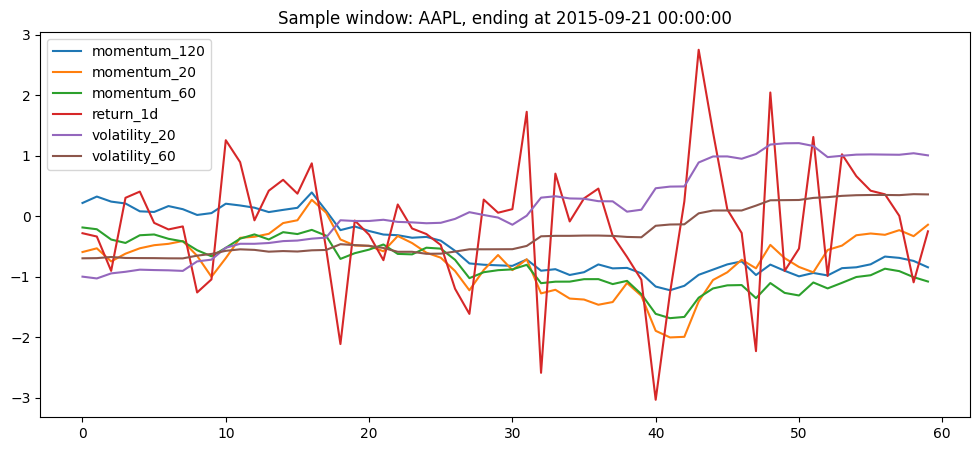

In [28]:
sample_idx = 0

sample = X_scaled[sample_idx]
sample_ticker = sample_tickers[sample_idx]
sample_date = sample_dates[sample_idx]

plt.figure(figsize=(12, 5))

for j, feature in enumerate(feature_names):
    plt.plot(sample[:, j], label=feature)

plt.title(f"Sample window: {sample_ticker}, ending at {sample_date}")
plt.legend()
plt.show()

In [29]:
print("X shape:", X_scaled.shape)

print("Mean:", X_scaled.mean())
print("Std:", X_scaled.std())

print("Min:", X_scaled.min())
print("Max:", X_scaled.max())

X shape: (70080, 60, 6)
Mean: -2.3758010272444545e-13
Std: 0.9999995566392901
Min: -17.200220336717713
Max: 25.491014551413297


In [30]:
unique_tickers = np.unique(sample_tickers)

print("Number of tickers:", len(unique_tickers))
print(unique_tickers[:10])

Number of tickers: 30
['AAPL' 'ABBV' 'ADBE' 'AMD' 'AMZN' 'AVGO' 'BAC' 'COST' 'CRM' 'CSCO']


In [31]:
print(sample_dates.min())
print(sample_dates.max())

2015-09-21 00:00:00
2024-12-31 00:00:00
